# Implementation and testing of a ResNet50-based model aimed at creating vector representations for images based on ear biometrics

## 1. Import libraries and environment configuration

**Section Goal:** Import necessary scientific libraries and configure system parameters.  

- Libraries like TensorFlow/Keras provide infrastructure for deep learning
- Matplotlib and scikit-learn enable model visualization and evaluation
- Setting deterministic random seeds ensures reproducibility of results
- Image standardization to 224x224 suitable for the ResNet50 model


In [ ]:
!unzip /content/augmented_ears.zip

In [ ]:
!unzip /content/nowe_ucho.zip

In [ ]:
#Section 1: Import libraries and configuration
import random
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from pathlib import Path
from keras import layers, losses, ops, optimizers, metrics, Model
from keras.applications import resnet
from sklearn.metrics import roc_curve, auc
from sklearn.manifold import TSNE
import pickle
from keras.callbacks import EarlyStopping

#Set seeds for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

#Parameter configuration
target_shape = (224, 224)  #Standard size for ResNet50
users_dir = Path("/content/augmented_ears")  # Main dataset
new_ear_dir = Path("nowe_ucho")  #New data for validation
margin = 0.7  #Margin for Triplet Loss function
model_save_path = "ear_authentication_model.h5"
image_to_user_map_path = "image_to_user_map.pkl"


## 2. Data preparation and triplet generation

**Section Goal:** Prepare data in triplet format for the Siamese network.  

- A triplet (anchor, positive, negative) is a standard data structure in similarity learning
- Anchors (reference images) are ear images (1 per ear) that haven't been augmented, serving as reference points for the model
- Triplets will be for each ear according to the rule:

 (reference image, next image from the given ear's folder, random anchor from another folder)
- Image-user mapping allows subsequent interpretation of results


In [ ]:
#Section 2: Data preparation
print("Ładowanie danych...")
user_folders = [f for f in users_dir.iterdir() if f.is_dir()]

#Split users into training and validation
random.shuffle(user_folders)
split_idx = int(0.8 * len(user_folders))
train_user_folders = user_folders[:split_idx]
val_user_folders = user_folders[split_idx:]

#Global list of all anchors
global_all_anchors = []

#Helper function to process user folders
def process_user_folders(user_folders):
    user_id_to_images = {}
    image_to_user = {}
    triplets = []
    local_anchors = []

    for i, user_folder in enumerate(user_folders):
        user_id = f"user_{i}"
        user_images = sorted([
            str(f) for f in user_folder.iterdir()
            if f.is_file() and f.suffix.lower() in ['.jpg', '.jpeg', '.png']
        ])

        if not user_images:
            continue

        anchors = [img for img in user_images if 'aug0' in img] or [user_images[0]]
        user_id_to_images[user_id] = {
            'anchor': anchors[0],
            'positives': [img for img in user_images if img != anchors[0]]
        }
        local_anchors.append(anchors[0])

        for img in user_images:
            image_to_user[img] = user_id

    user_ids = list(user_id_to_images.keys())
    for i, user_id_i in enumerate(user_ids):
        anchor_i = user_id_to_images[user_id_i]['anchor']
        positives_i = user_id_to_images[user_id_i]['positives']

        if not positives_i:
            continue

        for j, user_id_j in enumerate(user_ids):
            if i == j:
                continue

            anchor_j = user_id_to_images[user_id_j]['anchor']
            positive = random.choice(positives_i)
            triplets.append((anchor_i, positive, anchor_j))

    return triplets, image_to_user, local_anchors

#Process training and validation data
train_triplets, train_image_to_user, train_anchors = process_user_folders(train_user_folders)
val_triplets, val_image_to_user, val_anchors = process_user_folders(val_user_folders)

#Update global list of anchors
global_all_anchors = train_anchors + val_anchors

#Combine mappings for the whole set
image_to_user = {**train_image_to_user, **val_image_to_user}
with open(image_to_user_map_path, 'wb') as f:
    pickle.dump(image_to_user, f)

print(f"Wygenerowano {len(train_triplets)} tripletów treningowych i {len(val_triplets)} walidacyjnych")
print(f"Liczba wszystkich anchorów: {len(global_all_anchors)}")

Ładowanie danych...
Wygenerowano 40200 tripletów treningowych i 2550 walidacyjnych
Liczba wszystkich anchorów: 252


## 3. Preprocessing and dataset preparation

**Section Goal:** Prepare data for training in TensorFlow Dataset format.  

- JPEG decoding and pixel value normalization to [0,1] increases numerical stability
- Batching and prefetching optimize GPU utilization during training
- 80/20 split into training/validation set in line with model validation principles

In [ ]:
#Section 3: Image processing
def preprocess_image(filename):
    image_string = tf.io.read_file(filename)
    image = tf.image.decode_jpeg(image_string, channels=3)
    image = tf.image.convert_image_dtype(image, tf.float32)
    return tf.image.resize(image, target_shape)

def preprocess_triplets(anchor, positive, negative):
    return (
        preprocess_image(anchor),
        preprocess_image(positive),
        preprocess_image(negative),
    )

#Dataset preparation
train_dataset = tf.data.Dataset.from_tensor_slices((
    [t[0] for t in train_triplets],
    [t[1] for t in train_triplets],
    [t[2] for t in train_triplets]
)).shuffle(buffer_size=len(train_triplets)).map(preprocess_triplets).batch(32).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((
    [t[0] for t in val_triplets],
    [t[1] for t in val_triplets],
    [t[2] for t in val_triplets]
)).shuffle(buffer_size=len(val_triplets)).map(preprocess_triplets).batch(32).prefetch(tf.data.AUTOTUNE)


## 4. Embedding model architecture

**Section Goal:** Build a model generating biometric embeddings.  

- ResNet50 as backbone: proven CNN neural network architecture
- Transfer learning: use pre-trained weights on ImageNet
- Fine-tuning: unfreeze higher layers (conv5_block1_out+) to adapt to the problem being solved
- Dense layers with L2 regularization prevent overfitting
- L2 normalization: crucial for comparing distances between vectors

In [ ]:
#Section 4: Model architecture
base_cnn = resnet.ResNet50(
    weights="imagenet",
    input_shape=target_shape + (3,),
    include_top=False
)

x = base_cnn.output
x = layers.Flatten()(x)
x = layers.Dense(1024, activation='relu', kernel_regularizer='l2')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(512, activation='relu', kernel_regularizer='l2')(x)
x = layers.BatchNormalization()(x)

class L2Normalization(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
    def call(self, inputs):
        return tf.math.l2_normalize(inputs, axis=-1)

output = L2Normalization()(x)
embedding_model = Model(base_cnn.input, output, name="Embedding")

trainable = False
for layer in base_cnn.layers:
    if layer.name == "conv5_block1_out":
        trainable = True
    layer.trainable = trainable

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## 5. Siamese Network with Triplet Loss function

**Section Goal:** Implement the Siamese network architecture with a modified distance layer.  

- Siamese architecture: parallel processing of three inputs with shared weights
- Triplet Loss: minimizes anchor-positive distance, maximizes anchor-negative distance
- EuclideanDistance layer: calculates metrics based on Euclidean distances between vectors, necessary for the loss function
- Margin (0.7): hyperparameter controlling class separation in the embedding space

In [ ]:
#Section 5: Siamese Network
class EuclideanDistanceLayer(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
    def call(self, anchor, positive, negative):
        ap_distance = tf.norm(anchor - positive, axis=-1)
        an_distance = tf.norm(anchor - negative, axis=-1)
        return (ap_distance, an_distance)

anchor_input = layers.Input(name="anchor", shape=target_shape + (3,))
positive_input = layers.Input(name="positive", shape=target_shape + (3,))
negative_input = layers.Input(name="negative", shape=target_shape + (3,))

distances = EuclideanDistanceLayer()(
    embedding_model(resnet.preprocess_input(anchor_input)),
    embedding_model(resnet.preprocess_input(positive_input)),
    embedding_model(resnet.preprocess_input(negative_input))
)

siamese_network = Model(
    inputs=[anchor_input, positive_input, negative_input],
    outputs=distances
)

class SiameseModel(Model):
    def __init__(self, siamese_network, margin=0.7):
        super().__init__()
        self.siamese_network = siamese_network
        self.margin = margin
        self.loss_tracker = metrics.Mean(name="loss")

    def train_step(self, data):
        with tf.GradientTape() as tape:
            ap_dist, an_dist = self.siamese_network(data)
            loss = tf.maximum(tf.square(ap_dist) - tf.square(an_dist) + self.margin**2, 0.0)
        grads = tape.gradient(loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

    def test_step(self, data):
        ap_dist, an_dist = self.siamese_network(data)
        loss = tf.maximum(tf.square(ap_dist) - tf.square(an_dist) + self.margin**2, 0.0)
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

## 6. Model training

**Section Goal:** Process of training the model on prepared data.  

- Adam optimizer with 1e-4 learning rate: standard neural network optimizer
- 20 epochs: compromise between training time and loss function convergence
- Batch size 32: optimal use of GPU memory
- Validation loss monitoring: overfitting detection

In [ ]:
#Section 6: Training
siamese_model = SiameseModel(siamese_network, margin=margin)
siamese_model.compile(optimizer=optimizers.Adam(0.0001))

#Add EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = siamese_model.fit(
    train_dataset,
    epochs=20,
    validation_data=val_dataset,
    callbacks=[early_stopping]
)

Epoch 1/20
1257/1257 ━━━━━━━━━━━━━━━━━━━━ 488s 354ms/step - loss: 0.0457 - val_loss: 0.0126
Epoch 2/20
1257/1257 ━━━━━━━━━━━━━━━━━━━━ 459s 334ms/step - loss: 0.0089 - val_loss: 0.0123
Epoch 3/20
1257/1257 ━━━━━━━━━━━━━━━━━━━━ 420s 334ms/step - loss: 0.0049 - val_loss: 0.0144
Epoch 4/20
1257/1257 ━━━━━━━━━━━━━━━━━━━━ 443s 335ms/step - loss: 0.0044 - val_loss: 0.0113
Epoch 5/20
1257/1257 ━━━━━━━━━━━━━━━━━━━━ 442s 335ms/step - loss: 0.0035 - val_loss: 0.0075
Epoch 6/20
1257/1257 ━━━━━━━━━━━━━━━━━━━━ 442s 335ms/step - loss: 0.0028 - val_loss: 0.0049
Epoch 7/20
1257/1257 ━━━━━━━━━━━━━━━━━━━━ 420s 334ms/step - loss: 0.0014 - val_loss: 0.0059
Epoch 8/20
1257/1257 ━━━━━━━━━━━━━━━━━━━━ 441s 333ms/step - loss: 0.0015 - val_loss: 0.0039
Epoch 9/20
1257/1257 ━━━━━━━━━━━━━━━━━━━━ 420s 334ms/step - loss: 0.0014 - val_loss: 0.0054
Epoch 10/20
1257/1257 ━━━━━━━━━━━━━━━━━━━━ 442s 334ms/step - loss: 0.0010 - val_loss: 0.0050
Epoch 11/20
1257/1257 ━━━━━━━━━━━━━━━━━━━━ 443s 335ms/step - loss: 0.0013 - val

## 7. Biometric metrics evaluation

**Section Goal:** Calculate biometric system quality metrics.  

- ROC-AUC: classification quality metric based on the relationship between true positive rate and false positive rate
- FAR (False Acceptance Rate): % of unauthorized access
- FRR (False Rejection Rate): % of false rejections
- EER (Equal Error Rate): balance point of FAR/FRR - key metric in biometrics
- ROC Curve: visualizes FAR/FRR tradeoff to select the acceptable distance threshold between vectors

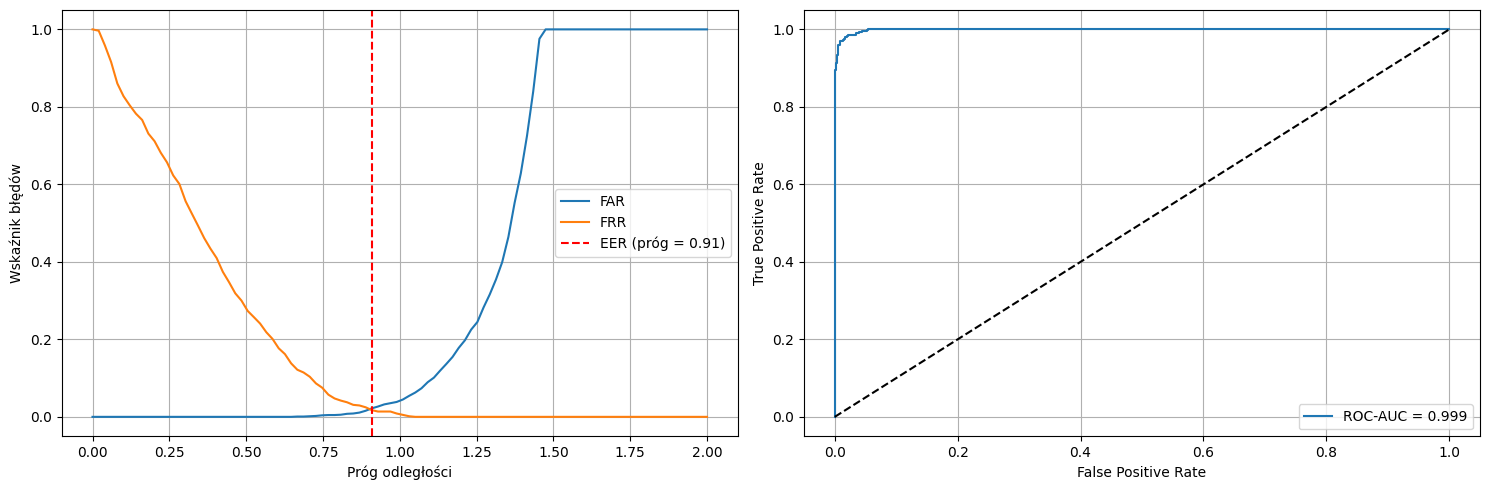


Podsumowanie metryk:
- ROC-AUC: 0.9988
- EER: 0.9091
- FAR przy EER: 0.0220
- FRR przy EER: 0.0173


In [ ]:
#Section 7: Metrics evaluation
def compute_biometric_metrics(model, dataset, thresholds=np.linspace(0, 2, 100)):
    #Calculate biometric metrics based on distances
    all_ap_dist, all_an_dist = [], []
    for anchor, positive, negative in dataset:
        ap_dist, an_dist = model.siamese_network([anchor, positive, negative])
        all_ap_dist.extend(ap_dist.numpy())
        all_an_dist.extend(an_dist.numpy())

    #Prepare data for ROC-AUC
    y_true = np.concatenate([np.ones_like(all_ap_dist), np.zeros_like(all_an_dist)])
    y_scores = np.concatenate([-np.array(all_ap_dist), -np.array(all_an_dist)])
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    #Calculate FAR and FRR
    far = [(np.array(all_an_dist) <= thresh).mean() for thresh in thresholds]
    frr = [(np.array(all_ap_dist) > thresh).mean() for thresh in thresholds]

    return roc_auc, thresholds, np.array(far), np.array(frr), fpr, tpr

#Calculate and present results
roc_auc, thresholds, far, frr, fpr, tpr = compute_biometric_metrics(siamese_model, val_dataset)
eer_idx = np.argmin(np.abs(far - frr))
eer_threshold = thresholds[eer_idx]

#Visualization
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(thresholds, far, label="FAR")
plt.plot(thresholds, frr, label="FRR")
plt.axvline(eer_threshold, color='red', linestyle='--', label=f'EER (próg = {eer_threshold:.2f})')
plt.xlabel("Próg odległości")
plt.ylabel("Wskaźnik błędów")
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid()

plt.tight_layout()
plt.savefig('metrics_visualization.png')
plt.show()

print(f"\nPodsumowanie metryk:")
print(f"- ROC-AUC: {roc_auc:.4f}")
print(f"- EER: {eer_threshold:.4f}")
print(f"- FAR przy EER: {far[eer_idx]:.4f}")
print(f"- FRR przy EER: {frr[eer_idx]:.4f}")

## 8. Embedding space analysis (t-SNE)

**Section Goal:** Visualize feature space using dimensionality reduction.  

- t-SNE: non-linear dimensionality reduction technique preserving local structures
- Map 6 random ears and 1 (black color) from outside the database in space
- Each ear on the plot has a different color. If the model works correctly -
groups of the same colors should be visible next to each other.


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 490ms/step


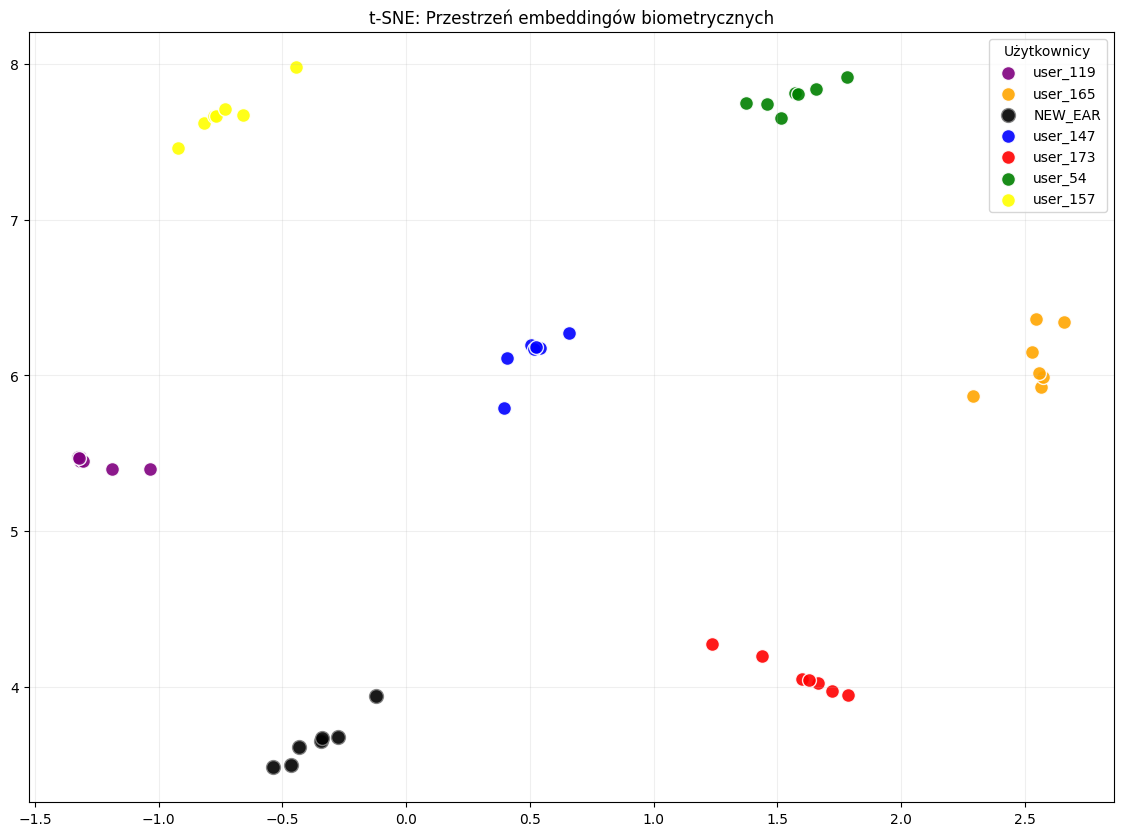

In [ ]:
#Section 8: Embedding visualization
def visualize_embeddings(embedding_model, image_to_user_map, new_ear_folder=new_ear_dir, samples_per_class=7):
    #Select random users
    all_users = list(set(image_to_user_map.values()))
    selected_users = random.sample(all_users, min(6, len(all_users)))

    #Defined color palette
    USER_COLORS = ['red', 'yellow', 'purple', 'green', 'blue', 'orange']
    NEW_EAR_COLOR = 'black'

    #Collect images with assigned colors
    images, labels, colors = [], [], []
    for idx, user_id in enumerate(selected_users):
        user_images = [img for img, uid in image_to_user_map.items() if uid == user_id]
        selected_images = random.sample(user_images, min(samples_per_class, len(user_images)))
        images.extend(selected_images)
        labels.extend([user_id] * len(selected_images))
        colors.extend([USER_COLORS[idx % len(USER_COLORS)]] * len(selected_images))

    #Add new ears (black color)
    if new_ear_folder.exists():
        new_ear_images = [str(f) for f in new_ear_folder.iterdir() if f.suffix.lower() in ['.jpg','.jpeg','.png']]
        selected_new_ears = new_ear_images[:min(samples_per_class, len(new_ear_images))]
        images.extend(selected_new_ears)
        labels.extend(["NEW_EAR"] * len(selected_new_ears))
        colors.extend([NEW_EAR_COLOR] * len(selected_new_ears))

    #Generate dataset
    data = tf.data.Dataset.from_tensor_slices(images)
    data = data.map(preprocess_image).batch(32)
    data = data.map(lambda x: resnet.preprocess_input(x))

    #Generate embeddings
    embeddings = embedding_model.predict(data, verbose=1)

    #t-SNE dimensionality reduction
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    embeddings_2d = tsne.fit_transform(embeddings)

    #Visualization
    plt.figure(figsize=(14, 10))
    unique_labels = set(labels)

    for label in unique_labels:
        #indices for the given label
        indices = [i for i, l in enumerate(labels) if l == label]

        #Use the first color from the list for this label
        color = colors[indices[0]] if indices else 'gray'

        plt.scatter(
            embeddings_2d[indices, 0],
            embeddings_2d[indices, 1],
            c=color,
            s=100,  #Larger points for better visibility
            alpha=0.9,
            label=label,
            edgecolors='w' if color != 'black' else 'gray',
            linewidths=1.0
        )

    plt.legend(title='Użytkownicy', loc='best')
    plt.title('t-SNE: Przestrzeń embeddingów biometrycznych')
    plt.grid(alpha=0.2)
    plt.savefig('embeddings_tsne.png', dpi=150, bbox_inches='tight')
    plt.show()

#Call visualization
visualize_embeddings(embedding_model, image_to_user)

## 9. Testing on new data and model saving

**Section Goal:** Validate the model on entirely new data and export the model.  

- Testing on an independent set: simulates real-world system usage
- EER threshold: optimal operating point for the biometric system
- Model saving in H5 format: ensures compatibility and deployment ease
- Verification example: demonstration of the system's operation on validation data

In [ ]:
#Section 9: Testing and saving
def test_new_ears(embedding_model, new_ear_folder=new_ear_dir, threshold=0.9):
    if not new_ear_folder.exists():
        return

    new_ear_images = [str(f) for f in new_ear_folder.iterdir() if f.suffix.lower() in ['.jpg','.jpeg','.png']]

    #Use the first anchor from the global list
    sample_anchor = preprocess_image(global_all_anchors[0])
    sample_embedding = embedding_model(resnet.preprocess_input(tf.expand_dims(sample_anchor, 0)))

    results = []
    for img_path in new_ear_images:
        img = preprocess_image(img_path)
        img_embedding = embedding_model(resnet.preprocess_input(tf.expand_dims(img, 0)))
        distance = tf.norm(sample_embedding - img_embedding).numpy()
        results.append((img_path, distance))

    #Results presentation
    for path, dist in results:
        print(f"{Path(path).name}: Distance = {dist:.4f}, Decision = {'YES' if dist <= threshold else 'NO'}")
    return results

#Test on new ears
new_ear_results = test_new_ears(embedding_model)

#Save model
embedding_model.save(model_save_path)

#Verification demonstration
def verify(anchor_emb, test_emb, threshold=eer_threshold):
    distance = tf.norm(anchor_emb - test_emb)
    return distance <= threshold, distance.numpy()

#Example from validation data
sample = next(iter(val_dataset))
anchor, positive, negative = sample
anchor_emb = embedding_model(resnet.preprocess_input(anchor[0:1]))
positive_emb = embedding_model(resnet.preprocess_input(positive[0:1]))
negative_emb = embedding_model(resnet.preprocess_input(negative[0:1]))

is_match, dist = verify(anchor_emb, positive_emb)
print(f"\nVerification (same user): {'Match' if is_match else 'No match'}, distance: {dist:.4f}")

is_match, dist = verify(anchor_emb, negative_emb)
print(f"Verification (different user): {'Match' if is_match else 'No match'}, distance: {dist:.4f}")

nowe3.jpg: Distance = 1.4105, Decision = NIE
nowe4.jpg: Distance = 1.4296, Decision = NIE
nowe2.jpg: Distance = 1.4364, Decision = NIE
nowe5.jpg: Distance = 1.4389, Decision = NIE
nowe7.jpg: Distance = 1.4321, Decision = NIE
nowe1.jpg: Distance = 1.4359, Decision = NIE
nowe6.jpg: Distance = 1.4333, Decision = NIE

Verification (same user): Match, distance: 0.2075
Verification (different user): No match, distance: 1.3660
